In [1]:
import uproot as up
import numpy as np
import matplotlib.pyplot as plt
import os
import utilities as util

from importlib import reload
reload(util)

from scipy.optimize import curve_fit

In [2]:
files_list = [filename for filename in os.listdir('./') if filename.endswith('.root') and 'Standoff' in filename]

lrfs_dict = {}

for file in files_list:
    print(file)
    # extract just the standoff and pmt part from the file name
    label = file.split('_')[2] + '_' + file.split('_')[3]
    graph = util.ExtractTGraph(file)
    lrfs_dict[label] = util.BinTGraph(graph.values()[0], graph.values()[1], bin_width=0.2, x_max=50.)

LRF_1cmS2_2cmStandoff_PMT25mm_AngleCutoff85.root
LRF_1cmS2_2cmStandoff_PMT50mm_AngleCutoff85.root
LRF_1cmS2_2cmStandoff_PMT6mm_AngleCutoff85.root


c:\Users\bglen\Research\XLZD\Jingke paper follow up\utilities.py:71: RuntimeWarning: invalid value encountered in divide
  err = np.sqrt( (n*1e4) * y_out * (1-y_out) ) / (n*1e4)


LRF_1cmS2_4cmStandoff_PMT25mm_AngleCutoff85.root
LRF_1cmS2_4cmStandoff_PMT50mm_AngleCutoff85.root
LRF_1cmS2_4cmStandoff_PMT6mm_AngleCutoff85.root
LRF_1cmS2_6cmStandoff_PMT25mm_AngleCutoff85.root
LRF_1cmS2_6cmStandoff_PMT50mm_AngleCutoff85.root
LRF_1cmS2_6cmStandoff_PMT6mm_AngleCutoff85.root


In [3]:
print(lrfs_dict.keys())

dict_keys(['2cmStandoff_PMT25mm', '2cmStandoff_PMT50mm', '2cmStandoff_PMT6mm', '4cmStandoff_PMT25mm', '4cmStandoff_PMT50mm', '4cmStandoff_PMT6mm', '6cmStandoff_PMT25mm', '6cmStandoff_PMT50mm', '6cmStandoff_PMT6mm'])


Size: PMT25mm, Standoff: 2cmStandoff
Size: PMT50mm, Standoff: 2cmStandoff
Size: PMT6mm, Standoff: 2cmStandoff
Size: PMT25mm, Standoff: 4cmStandoff
Size: PMT50mm, Standoff: 4cmStandoff
Size: PMT6mm, Standoff: 4cmStandoff
Size: PMT25mm, Standoff: 6cmStandoff
Size: PMT50mm, Standoff: 6cmStandoff
Size: PMT6mm, Standoff: 6cmStandoff


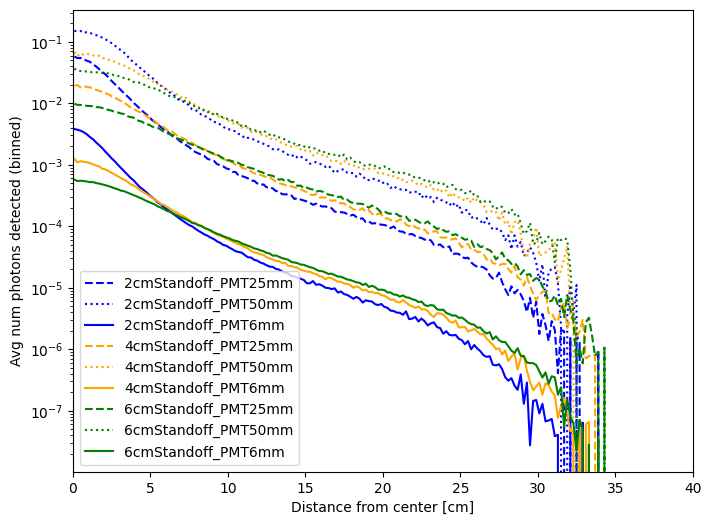

In [4]:
# Plot all the LRFs. Group by linestyle for the different PMT sizes and by color for the different standoffs
linestyles = {'PMT6mm': 'solid', 'PMT25mm': 'dashed', 'PMT50mm': 'dotted'}
colors = {'2cmStandoff': 'blue', '4cmStandoff': 'orange', '6cmStandoff': 'green'}

plt.figure(figsize=(8,6))
for label, (x, y, err) in lrfs_dict.items():
    pmt_size = label.split('_')[1]
    standoff = label.split('_')[0]
    print('Size: {}, Standoff: {}'.format(pmt_size, standoff))
    plt.plot(x, y, label=label, linestyle=linestyles[pmt_size], color=colors[standoff])
plt.ylabel('Avg num photons detected (binned)')
plt.xlabel('Distance from center [cm]') 
plt.yscale('log')
plt.xlim(0.,40.)
plt.legend()

Fit parameters:
  A = 0.0040 +/- 0.0000
  a = 1.0199 +/- 0.0075
  b = 4.3898 +/- 0.0567
  alpha = 1.7144 +/- 0.0133
  0 = 5.3306 +/- 0.0579


c:\Users\bglen\Research\XLZD\Jingke paper follow up\utilities.py:78: RuntimeWarning: divide by zero encountered in power
  return A * np.exp(-a * rho / (1 + rho**(1-alpha)) - b / (1 + rho**(-alpha)))
C:\Users\bglen\AppData\Local\Temp\ipykernel_33072\24713223.py:41: RuntimeWarning: divide by zero encountered in divide
  plt.errorbar(x, (y - util.fitfunc(x, *popt))/err, yerr=err, fmt='o', markersize=2)


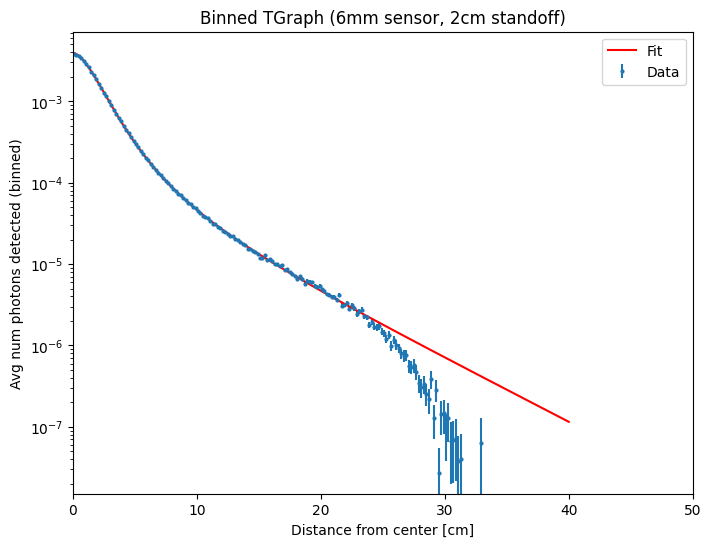

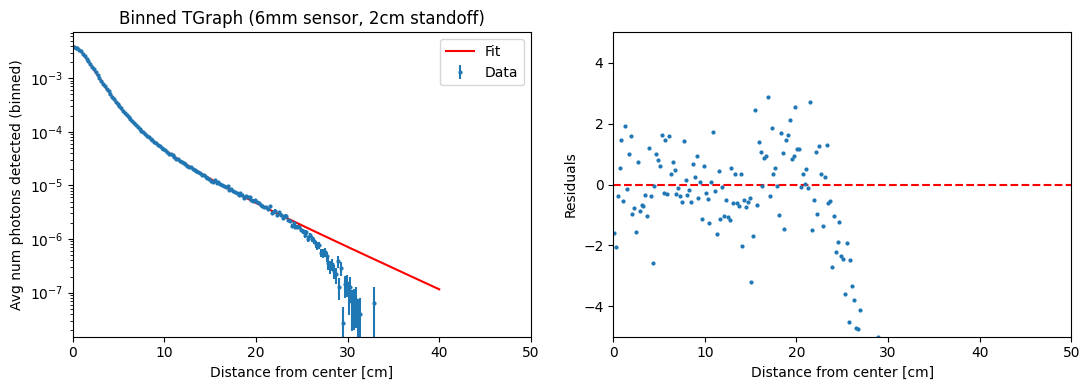

In [5]:
# Plot one of the LRFs and fit to the fit fuctinon
x, y, err = lrfs_dict['2cmStandoff_PMT6mm']

# Parameter order: A, a, b, alpha, r0
p0 = [0.004, 1.5, 4, 2, 6]

fit_range = (x > 0) & (x < 25)
popt, pcov = curve_fit(util.fitfunc, x[fit_range], y[fit_range], p0=p0, sigma=err[fit_range], absolute_sigma=True, maxfev=10000)

# popt, pcov = curve_fit(fitfunc, x, y, p0=p0, sigma=err, absolute_sigma=True, maxfev=10000)
perr = np.sqrt(np.diag(pcov))
print('Fit parameters:')
for i, param in enumerate(['A', 'a', 'b', 'alpha', '0']):
    print('  {} = {:.4f} +/- {:.4f}'.format(param, popt[i], perr[i]))   
    
plt.figure(figsize=(8,6))
plt.errorbar(x, y, yerr=err, fmt='o', markersize=2, label='Data')
x_fit = np.linspace(0., 40., 200)
y_fit = util.fitfunc(x_fit, *popt)
plt.plot(x_fit, y_fit, label='Fit', color='red')
plt.ylabel('Avg num photons detected (binned)')
plt.xlabel('Distance from center [cm]')
plt.yscale('log')

# Plot figure and also residuals
plt.title('Binned TGraph (6mm sensor, 2cm standoff)')
plt.xlim(0.,50.)

plt.legend()
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.errorbar(x, y, yerr=err, fmt='o', markersize=2, label='Data')
plt.plot(x_fit, y_fit, label='Fit', color='red')
plt.ylabel('Avg num photons detected (binned)')
plt.xlabel('Distance from center [cm]')
plt.yscale('log')
plt.title('Binned TGraph (6mm sensor, 2cm standoff)')
plt.xlim(0.,50.)
plt.legend()
plt.subplot(1,2,2)
plt.errorbar(x, (y - util.fitfunc(x, *popt))/err, yerr=err, fmt='o', markersize=2)
plt.axhline(0., color='red', linestyle='--')
plt.ylabel('Residuals')
plt.xlabel('Distance from center [cm]')
plt.xlim(0.,50.)
plt.tight_layout()
plt.ylim(-5.,5.)
plt.show()


Fitting 2cmStandoff_PMT25mm
Fit parameters:
  A = 0.0580 +/- 0.0002
  a = 0.8961 +/- 0.0037
  b = 4.1537 +/- 0.0352
  alpha = 1.9143 +/- 0.0097
  r0 = 5.4316 +/- 0.0338
Fitting 2cmStandoff_PMT50mm
Fit parameters:
  A = 0.1505 +/- 0.0004
  a = 0.8669 +/- 0.0035
  b = 3.3186 +/- 0.0299
  alpha = 2.4288 +/- 0.0122
  r0 = 5.7868 +/- 0.0285
Fitting 2cmStandoff_PMT6mm
Fit parameters:
  A = 0.0040 +/- 0.0000
  a = 1.0199 +/- 0.0075
  b = 4.3898 +/- 0.0567
  alpha = 1.7144 +/- 0.0133
  r0 = 5.3306 +/- 0.0579
Fitting 4cmStandoff_PMT25mm
Fit parameters:
  A = 0.0195 +/- 0.0001
  a = 1.1568 +/- 0.0090
  b = 2.8009 +/- 0.0536
  alpha = 2.0484 +/- 0.0183
  r0 = 7.1197 +/- 0.0866
Fitting 4cmStandoff_PMT50mm
Fit parameters:
  A = 0.0644 +/- 0.0002
  a = 1.0911 +/- 0.0066
  b = 2.6973 +/- 0.0563
  alpha = 2.2351 +/- 0.0190
  r0 = 7.8511 +/- 0.0899
Fitting 4cmStandoff_PMT6mm
Fit parameters:
  A = 0.0012 +/- 0.0000
  a = 1.1961 +/- 0.0142
  b = 3.0417 +/- 0.0831
  alpha = 1.9611 +/- 0.0250
  r0 = 7.2018

Text(0.5, 1.0, 'Fit to Binned TGraph')

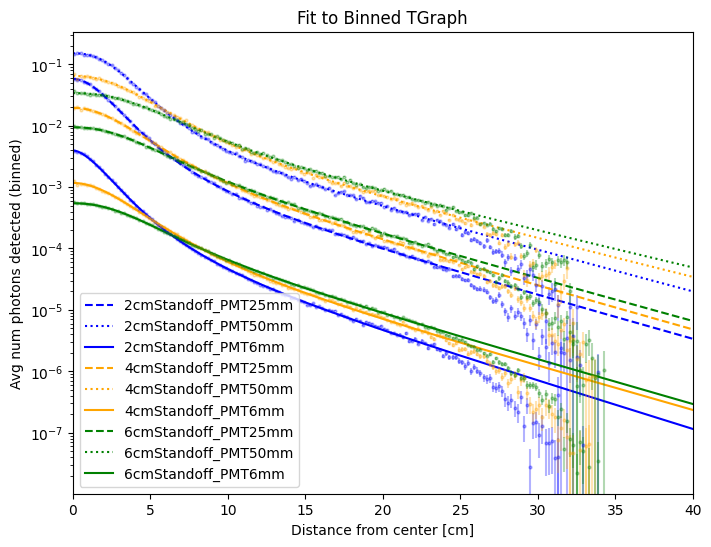

In [6]:
# Fit all the LRFs and store the fit parameters in a dictionary
fit_params_dict = {}
for label, (x, y, err) in lrfs_dict.items():
    print('Fitting {}'.format(label))
    p0 = [0.004, 1.5, 4, 2, 6]
    fit_range = (x > 0) & (x < 25)
    popt, pcov = curve_fit(util.fitfunc, x[fit_range], y[fit_range], p0=p0, sigma=err[fit_range], absolute_sigma=True, maxfev=10000)
    perr = np.sqrt(np.diag(pcov))
    fit_params_dict[label] = (popt, perr)
    print('Fit parameters:')
    for i, param in enumerate(['A', 'a', 'b', 'alpha', 'r0']):
        print('  {} = {:.4f} +/- {:.4f}'.format(param, popt[i], perr[i]))
        
plt.figure(figsize=(8,6))
for label, (x, y, err) in lrfs_dict.items():
    pmt_size = label.split('_')[1]
    standoff = label.split('_')[0]
    popt, perr = fit_params_dict[label]
    x_fit = np.linspace(0., 40., 200)
    y_fit = util.fitfunc(x_fit, *popt)
    plt.plot(x_fit, y_fit, label=label, linestyle=linestyles[pmt_size], color=colors[standoff])
    plt.errorbar(x, y, yerr=err, fmt='o', markersize=2, alpha=0.3, color=colors[standoff])
plt.ylabel('Avg num photons detected (binned)')
plt.xlabel('Distance from center [cm]')
plt.yscale('log')
plt.xlim(0.,40.)
plt.legend()
plt.title('Fit to Binned TGraph')

In [7]:
print(fit_params_dict)       
# Save the fitted dictionary as a pickle file
import pickle
with open('lrf_fit_params.pkl', 'wb') as f:
    pickle.dump(fit_params_dict, f)


{'2cmStandoff_PMT25mm': (array([0.05799159, 0.89613062, 4.15369328, 1.91425601, 5.43158487]), array([0.00020269, 0.00373003, 0.03518984, 0.00973463, 0.03377868])), '2cmStandoff_PMT50mm': (array([0.15053969, 0.86689342, 3.31861272, 2.4287815 , 5.78683302]), array([0.00039973, 0.00348922, 0.02994497, 0.01215121, 0.02849952])), '2cmStandoff_PMT6mm': (array([3.95460196e-03, 1.01987341e+00, 4.38984617e+00, 1.71444834e+00,
       5.33055878e+00]), array([2.25597271e-05, 7.47427786e-03, 5.67261944e-02, 1.32751929e-02,
       5.78511436e-02])), '4cmStandoff_PMT25mm': (array([0.01949868, 1.15676301, 2.80086073, 2.04841261, 7.11968652]), array([8.19326873e-05, 8.96049270e-03, 5.36025026e-02, 1.82544321e-02,
       8.66211258e-02])), '4cmStandoff_PMT50mm': (array([0.06437418, 1.09113482, 2.69734705, 2.23505341, 7.85105395]), array([0.00023078, 0.00664855, 0.05631495, 0.0190484 , 0.08993624])), '4cmStandoff_PMT6mm': (array([1.16869386e-03, 1.19608193e+00, 3.04172149e+00, 1.96109878e+00,
       7.2

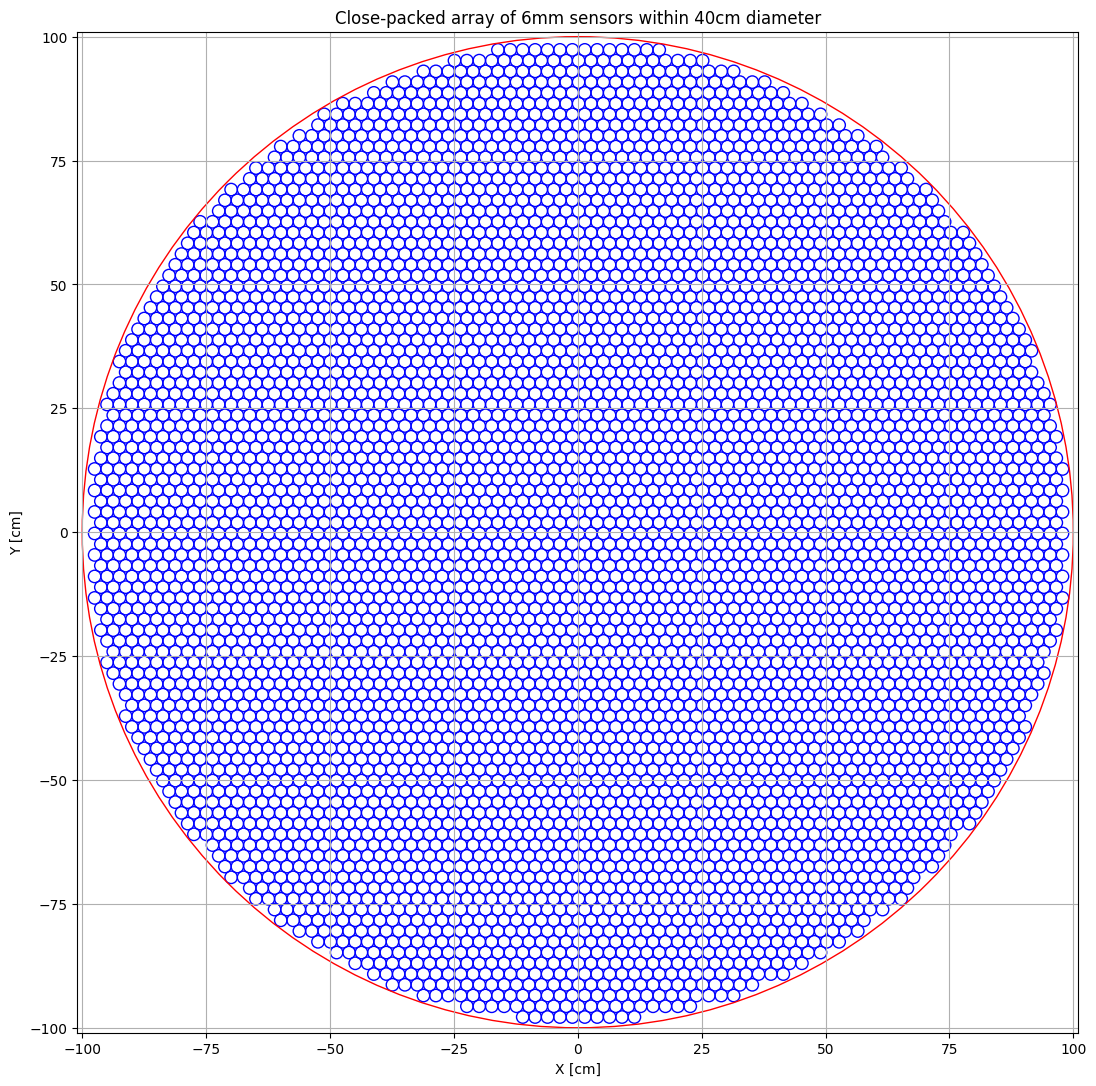

In [8]:
# Plot the array using circles to represent the sensors and a larger circle to represent the array boundary
sensor_radius = 1.252  # cm (6mm diameter)
array_radius = 100.0  # cm
positions = util.create_hex_close_packed_array(sensor_radius, array_radius)
plt.figure(figsize=(13,13))
# plt.scatter(positions[:,0], positions[:,1], s=100)
for (x, y) in positions:
    circle = plt.Circle((x, y), sensor_radius, color='b', fill=False)
    plt.gca().add_artist(circle)
circle = plt.Circle((0, 0), array_radius, color='r', fill=False)
plt.gca().add_artist(circle)
plt.xlim(-array_radius-1, array_radius+1)
plt.ylim(-array_radius-1, array_radius+1)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Close-packed array of 6mm sensors within 40cm diameter')
plt.xlabel('X [cm]')
plt.ylabel('Y [cm]')
plt.grid()
plt.show()


In [9]:
# Choose a random point in the array and use the LRFs to simulate the response of the array. Assume we pass the function the fit parameters for a single LRF, which is then
# parameterized by fitfunc. Use Poisson statistics to simulate the response of each sensor.



In [10]:
print(fit_params_dict.keys())
print(fit_params_dict['2cmStandoff_PMT25mm'])

dict_keys(['2cmStandoff_PMT25mm', '2cmStandoff_PMT50mm', '2cmStandoff_PMT6mm', '4cmStandoff_PMT25mm', '4cmStandoff_PMT50mm', '4cmStandoff_PMT6mm', '6cmStandoff_PMT25mm', '6cmStandoff_PMT50mm', '6cmStandoff_PMT6mm'])
(array([0.05799159, 0.89613062, 4.15369328, 1.91425601, 5.43158487]), array([0.00020269, 0.00373003, 0.03518984, 0.00973463, 0.03377868]))


In [11]:
# Now, for an event in the center of the array, simulate the response of the array for 100 photons using the simulate_array_response function
event_point = np.array([0., 0.])
num_photons = 500 * 1e5
sensor_radius = 0.6 # cm (6mm diameter)
array_radius = 50.0  # cm
positions = util.create_hex_close_packed_array(sensor_radius, array_radius)
responses, total_photons_detected, max_photons_in_one_sensor = util.simulate_array_response(event_point, num_photons, positions, fit_params_dict['2cmStandoff_PMT25mm'][0], saturation_smearing_percent=10.)
responses2, total_photons_detected2, max_photons_in_one_sensor2 = util.simulate_array_response(event_point + np.array([5.,5.]), int(num_photons/10), positions, fit_params_dict['2cmStandoff_PMT25mm'][0], saturation_smearing_percent=10.)
responses += responses2
print('Total photons detected: {}'.format(total_photons_detected))
print('Max photons in one sensor: {} (sqrt(N)/N = {:.3f}%)'.format(max_photons_in_one_sensor, np.sqrt(max_photons_in_one_sensor)/max_photons_in_one_sensor*100.))
mask = responses > 0
print('Number of sensors with non-zero response: {} out of {}'.format(np.sum(mask), len(responses)))
print(responses[mask])


Total photons detected: 22124447.90487066
Max photons in one sensor: 631212.7543470388 (sqrt(N)/N = 0.126%)
Number of sensors with non-zero response: 6145 out of 6145
[13.28372284 10.46528684  6.60542348 ...  8.8232626  12.44917636
 15.4812499 ]


C:\Users\bglen\AppData\Local\Temp\ipykernel_33072\2893198598.py:29: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label='Num photons detected')


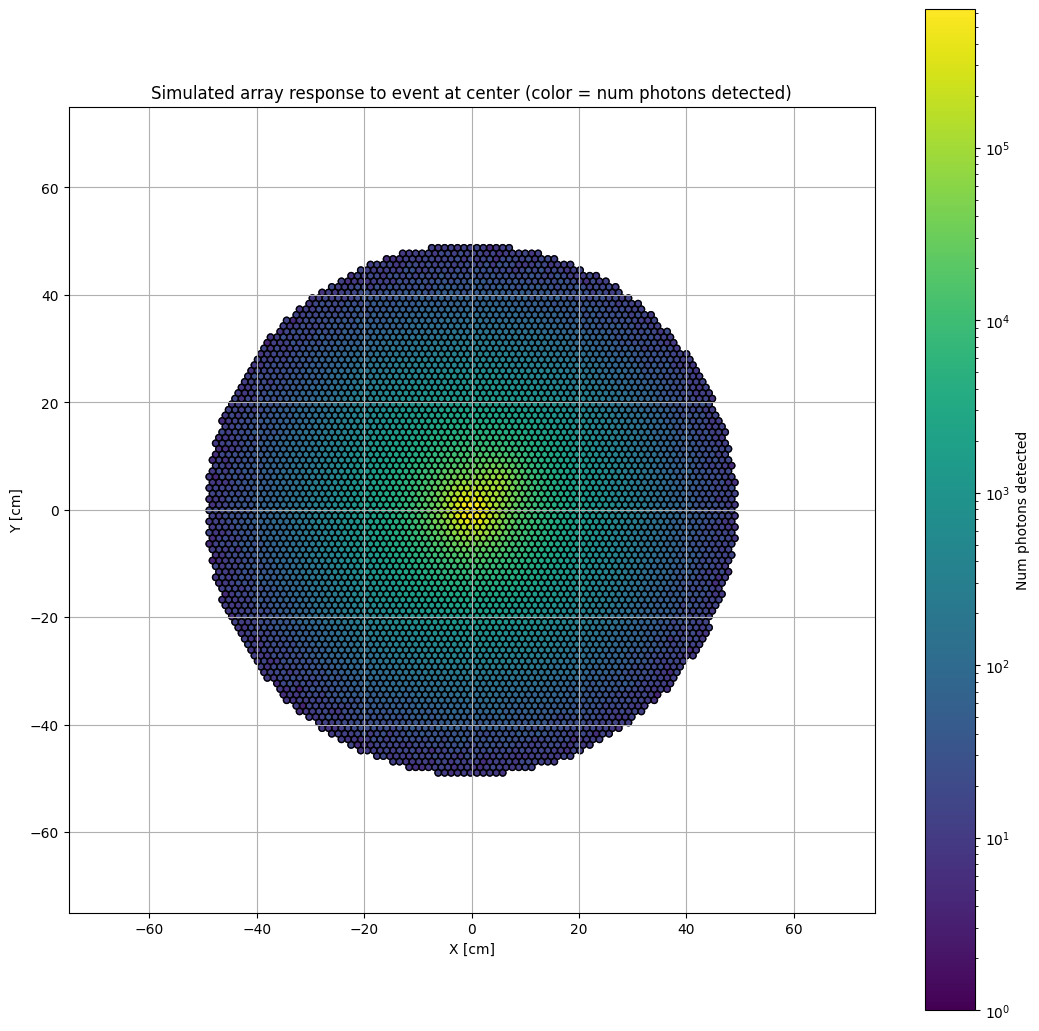

In [12]:
from matplotlib.colors import LogNorm

# Now plot the responses on the array using a color scale to represent the number of photons detected by each sensor. Use a log scale for the color scale

plt.figure(figsize=(13,13))


# Scale the responses to a color within the viridis color scale. Use a log scale.
norm = LogNorm(vmin=1, vmax=np.max(responses))
cmap = plt.get_cmap('viridis')
for (x, y), response in zip(positions, responses):
    color = cmap(norm(response))
    circle = plt.Circle((x, y), sensor_radius, color=color, fill=True)
    plt.gca().add_artist(circle)
    
    
plt.xlim(-array_radius-1, array_radius+1)
plt.ylim(-array_radius-1, array_radius+1)
plt.xlim(-75, 75)
plt.ylim(-75, 75)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Simulated array response to event at center (color = num photons detected)')
plt.xlabel('X [cm]')
plt.ylabel('Y [cm]')

# add a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, label='Num photons detected')
plt.grid()

# Now plot the array as open black circles so we can see the sensor positions
for (x, y) in positions:
    circle = plt.Circle((x, y), sensor_radius, color='k', fill=False)
    plt.gca().add_artist(circle)
plt.show()


C:\Users\bglen\AppData\Local\Temp\ipykernel_34812\3566706597.py:27: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label='Num photons detected')


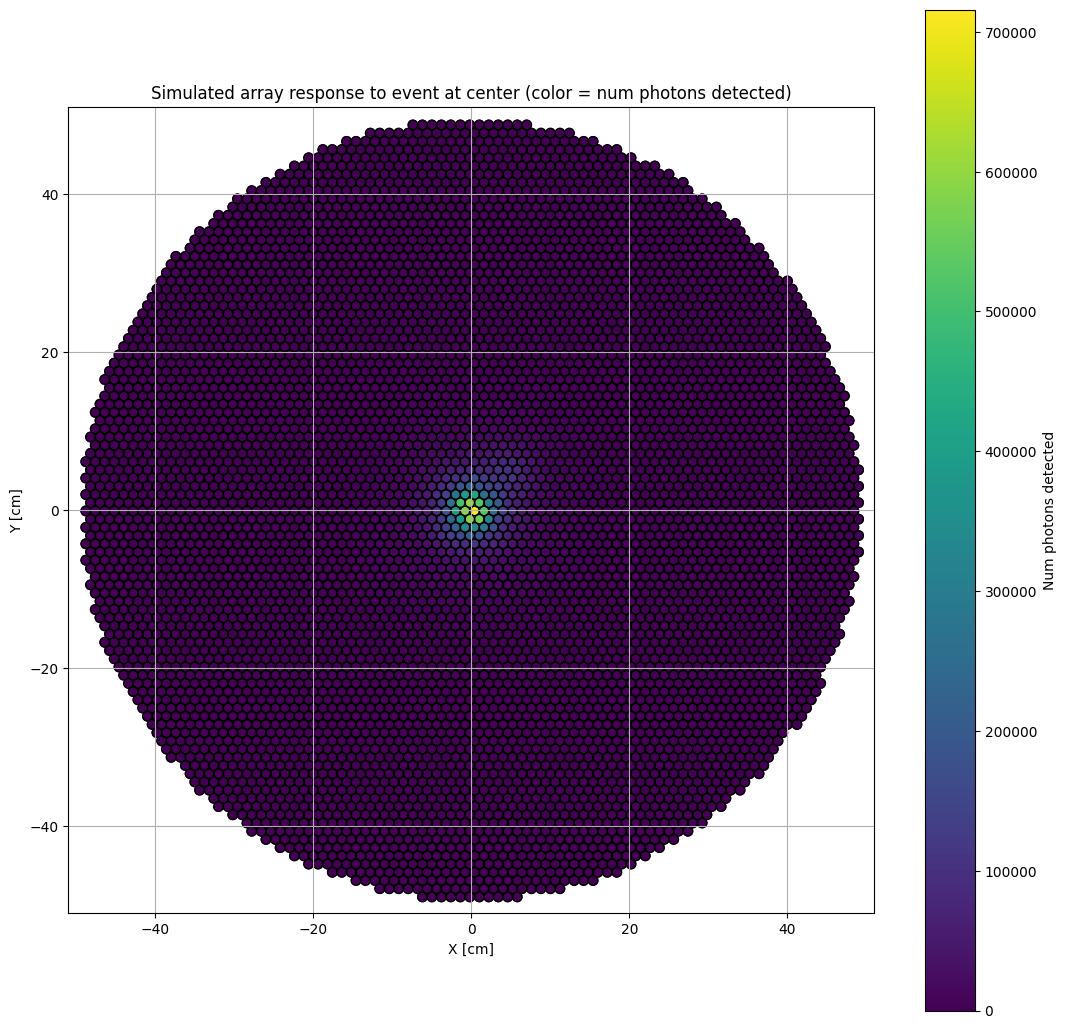

In [60]:
from matplotlib.colors import Normalize

# Now plot the responses on the array using a color scale to represent the number of photons detected by each sensor. Use a log scale for the color scale

plt.figure(figsize=(13,13))


# Scale the responses to a color within the viridis color scale. Use a log scale.
norm = Normalize(vmin=0, vmax=np.max(responses))
cmap = plt.get_cmap('viridis')
for (x, y), response in zip(positions, responses):
    color = cmap(norm(response))
    circle = plt.Circle((x, y), sensor_radius, color=color, fill=True)
    plt.gca().add_artist(circle)
    
    
plt.xlim(-array_radius-1, array_radius+1)
plt.ylim(-array_radius-1, array_radius+1)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Simulated array response to event at center (color = num photons detected)')
plt.xlabel('X [cm]')
plt.ylabel('Y [cm]')

# add a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, label='Num photons detected')
plt.grid()

# Now plot the array as open black circles so we can see the sensor positions
for (x, y) in positions:
    circle = plt.Circle((x, y), sensor_radius, color='k', fill=False)
    plt.gca().add_artist(circle)
plt.show()
